# Portfolio Replica — Modelling & Backtesting

Replicates a target index using liquid Futures contracts via rolling Elastic Net and a Kalman Filter.

**Pipeline:** OLS baseline → Regularized rolling backtest → Kalman Filter → Model comparison

## Notebook Structure

0. Setup
1. OLS Baseline (In-Sample)
2. Hyperparameter Search — Elastic Net
3. Rolling Backtest
4. Weight Evolution
5. Rebalancing Frequency Analysi
6. Kalman Filter — Process Noise Sensitivity
7. Model Comparison for index HFRXGL
8. MXWO
9. MXWD
10. LEGATRUU
11. Unconstrained Markowitz 
12. Constrained Markowitz
13. Final Comparison

---
## 0. Setup

In [1]:
import warnings

from plots import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from utilities import analizza_target
from Backtest import RollingBacktester
from optimization import HyperparameterOptimizer
from Model_Runner import ModelRunner
from Kalman_Filter import KalmanFilterStrategy

warnings.filterwarnings('ignore')

all_returns = pd.read_pickle("all_returns_data.pkl")
print(f"Data loaded: {all_returns.shape[0]} weeks × {all_returns.shape[1]} columns")
print(f"Period: {all_returns.index[0].date()} → {all_returns.index[-1].date()}")

Data loaded: 704 weeks × 18 columns
Period: 2007-10-30 → 2021-04-20


In [2]:
# ── Targets & Predictors ──────────────────────────────────────────────────
FUTURES = ["RX1", "TY1", "GC1", "CO1", "ES1",
           "VG1", "NQ1", "LLL1", "TP1", "DU1", "TU2"]

MAIN_TARGET = "HFRXGL"   # Change to "MXWD", "MXWO", etc. to test others

y = all_returns[MAIN_TARGET]
X = all_returns[FUTURES]

ANNUAL_FACTOR = 52

# ── Backtester (shared settings across all models) ────────────────────────
bt = RollingBacktester(
    rolling_window=156,
    rebalance_every=12,
    var_threshold=0.20,
    var_confidence=0.01,
    var_horizon=4,
    transaction_cost_bps=5.0,
    annual_factor=ANNUAL_FACTOR
)

runner = ModelRunner(bt, X, y)

print(f"Target: {MAIN_TARGET}")
print(f"Futures: {FUTURES}")

Target: HFRXGL
Futures: ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']


---
## 1. OLS Baseline (In-Sample)

OLS on the full history gives an **optimistic ceiling** — it uses future data so it cannot be deployed. Use it to understand which futures matter and what the best achievable fit looks like.

=== OLS Baseline (In-Sample) ===
  R²               : 0.2745
  Tracking Error   : 4.07%
  Correlation      : 0.5243
  Gross Exposure   : 0.98x

           TU2     ES1     TY1     RX1     DU1     TP1    LLL1     NQ1  \
Weight -0.4272  0.1361  0.1129  0.1023 -0.0579  0.0474 -0.0266 -0.0263   

           GC1     CO1     VG1  
Weight -0.0155  0.0154 -0.0099  


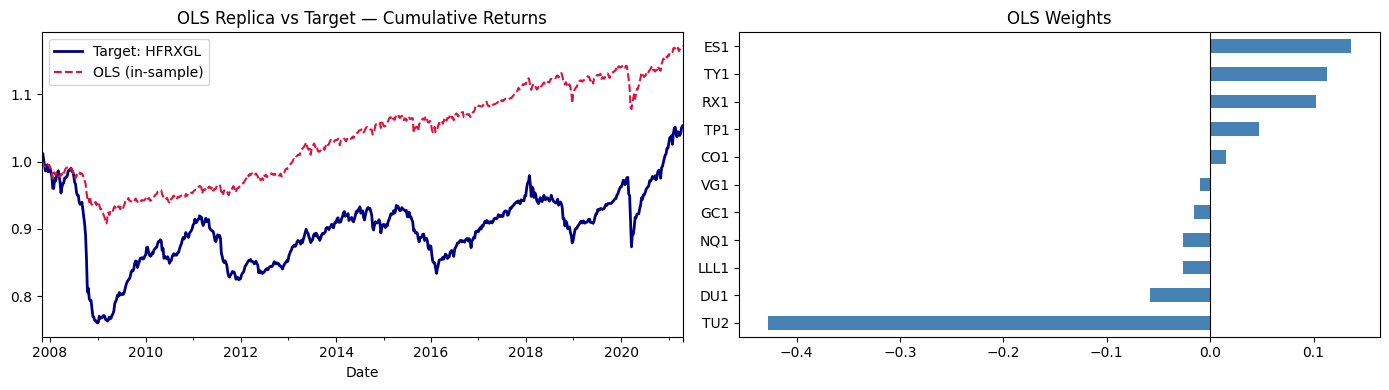

In [3]:
ols = LinearRegression(fit_intercept=False)
ols.fit(X.values, y.values)

ols_weights  = pd.Series(ols.coef_, index=X.columns)
ols_replica  = X @ ols_weights
ols_te       = (ols_replica - y).std() * np.sqrt(ANNUAL_FACTOR)

print(f"=== OLS Baseline (In-Sample) ===")
print(f"  R²               : {ols.score(X, y):.4f}")
print(f"  Tracking Error   : {ols_te*100:.2f}%")
print(f"  Correlation      : {ols_replica.corr(y):.4f}")
print(f"  Gross Exposure   : {ols_weights.abs().sum():.2f}x")
print()
print(ols_weights.sort_values(key=abs, ascending=False).round(4).to_frame("Weight").T)

plot_model_performance(y, ols_replica, ols_weights, model_name="OLS")


---
## 2. Hyperparameter Search — Elastic Net

We search over `alpha` (regularization strength) and `l1_ratio` (Lasso vs Ridge blend - we start from 0.1 and arrive to 0.9 becouse we use after the Ridge and Lasso) using the `HyperparameterOptimizer`, which runs the rolling backtest on a fast subsample and ranks by Tracking Error.

**Note:** `sample_size=200` keeps the search fast, you can use None to use the full data

In [4]:
optimizer = HyperparameterOptimizer(bt, X, y)

param_grid = {
    "alpha":     [0.0001, 0.001, 0.01],
    "l1_ratio":  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
}

grid_results, best_params, best_te = optimizer.grid_search(
    model_class=ElasticNet,
    param_grid=param_grid,
    n_jobs=-1,
    sample_size=None
)

print(f"Best params : {best_params}")
print(f"Best TE     : {best_te*100:.2f}%")
display(grid_results.head(10).reset_index(drop=True))

Best params : {'alpha': 0.01, 'l1_ratio': 0.1}
Best TE     : 3.92%


,alpha,l1_ratio,TE
0,0.010,0.1,0.039193
1,0.010,0.2,0.039433
2,0.001,0.9,0.039684
3,0.001,0.8,0.040045
4,0.001,0.7,0.040395
5,0.001,0.6,0.040742
6,0.001,0.5,0.041188
7,0.001,0.4,0.041772
8,0.010,0.3,0.041991
9,0.001,0.3,0.042308


---
## 3. Rolling Backtest

We run four models out-of-sample and compare them:
- `Ridge`
- `Lasso`
- `ElasticNet` - with parameters find before
- `Kalman`

The rolling window trains on the past 104 weeks and predicts the next week — no look-ahead.

VaR is computed using a Student-t fit (better than Gaussian for fat-tailed returns) and weights are scaled down if the 1-month 99% VaR exceeds 20% (UCITS limit).

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,3.679,4.462,4.507,0.471,0.438,2.380
Lasso,2.670,3.079,3.924,0.474,0.246,0.285
Elastic Net,2.656,3.062,3.920,0.474,0.243,0.283
Kalman,1.987,2.944,4.031,0.421,0.013,1.407


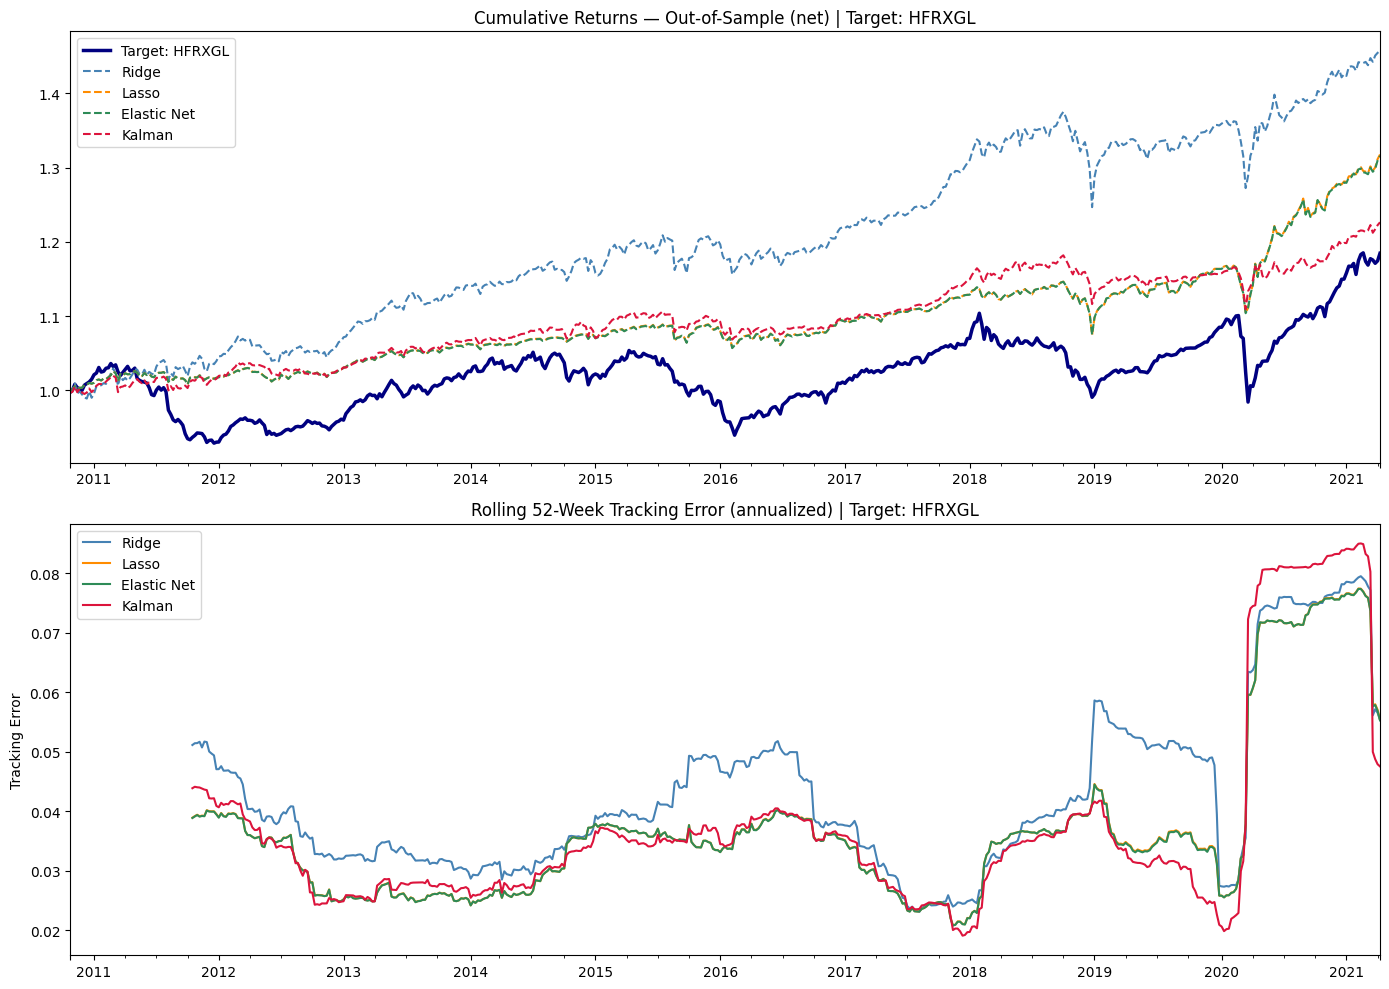

In [5]:
models = {
    "Ridge":       Ridge(alpha=0.01, fit_intercept=False),
    "Lasso":       Lasso(alpha=0.001, fit_intercept=False, max_iter=5000),
    "Elastic Net": ElasticNet(**best_params, fit_intercept=False, max_iter=5000),
    "Kalman":      KalmanFilterStrategy(init_window=104, process_noise=1e-4,
                                        transaction_cost_bps=5.0),
}

results = runner.run_models(models)

# Summary table
metrics_df = pd.DataFrame({
    name: res["metrics"] for name, res in results.items()
}).T.round(3)

styled_df = metrics_df.style.apply(highlight_best, axis=0).format(precision=3)

print("=== Out-of-Sample Performance (net of transaction costs) ===")
display(styled_df)
fig, axes, common_idx, target_oos = plot_oos_comparison(results, y, annual_factor=52)

# Portfolio Replication Backtest: Out-of-Sample Results Summary

### Key Observations & Model Behaviors
### Lasso & Elastic Net: Efficient and Sparse (The Best Replicators)
Lasso and Elastic Net behave almost identically and represent the most faithful replication strategies. They exhibit a drastically lower Average Gross Exposure (~0.28x) compared to Ridge (2.38x). This indicates that the L1 penalty effectively zeros out irrelevant futures, resulting in a highly sparse and efficient portfolio. As a result, they successfully achieve the lowest Tracking Error (~3.92%) and the highest Correlation (0.474) to the target, providing a stable and conservative replication without taking on unnecessary leverage.

### Ridge is Over-Leveraged (High Gross Exposure)
Ridge achieved the highest annualized return (3.679%) and the highest Information Ratio (0.438). However, this comes at the cost of high annualized volatility (4.462%) and the highest Tracking Error (4.507%). Because the L2 penalty shrinks weights but never forces them exactly to zero, Ridge takes on a massive Average Gross Exposure (2.38x). This creates a highly leveraged, unstable portfolio where long and short positions cancel each other out but still generate excessive transaction costs and replication drag in the real world.

### Kalman Filter is Drifting (Momentum vs. Tracking)
The Kalman Filter achieved the highest absolute return (1.987%) and the only positive Information Ratio (0.013). However, it behaves poorly as a strict replication tool: it has the highest Tracking Error (4.031%) and the lowest Correlation (0.421) to the target. Because it is an online learner that adapts dynamically step-by-step, it is effectively acting as an active momentum strategy rather than a faithful shadow of the target portfolio.


---
## 4. Weight Evolution

How each model allocates across futures over time. Sparse models (Lasso, Elastic Net) will show many zero weights — fewer positions to rebalance.

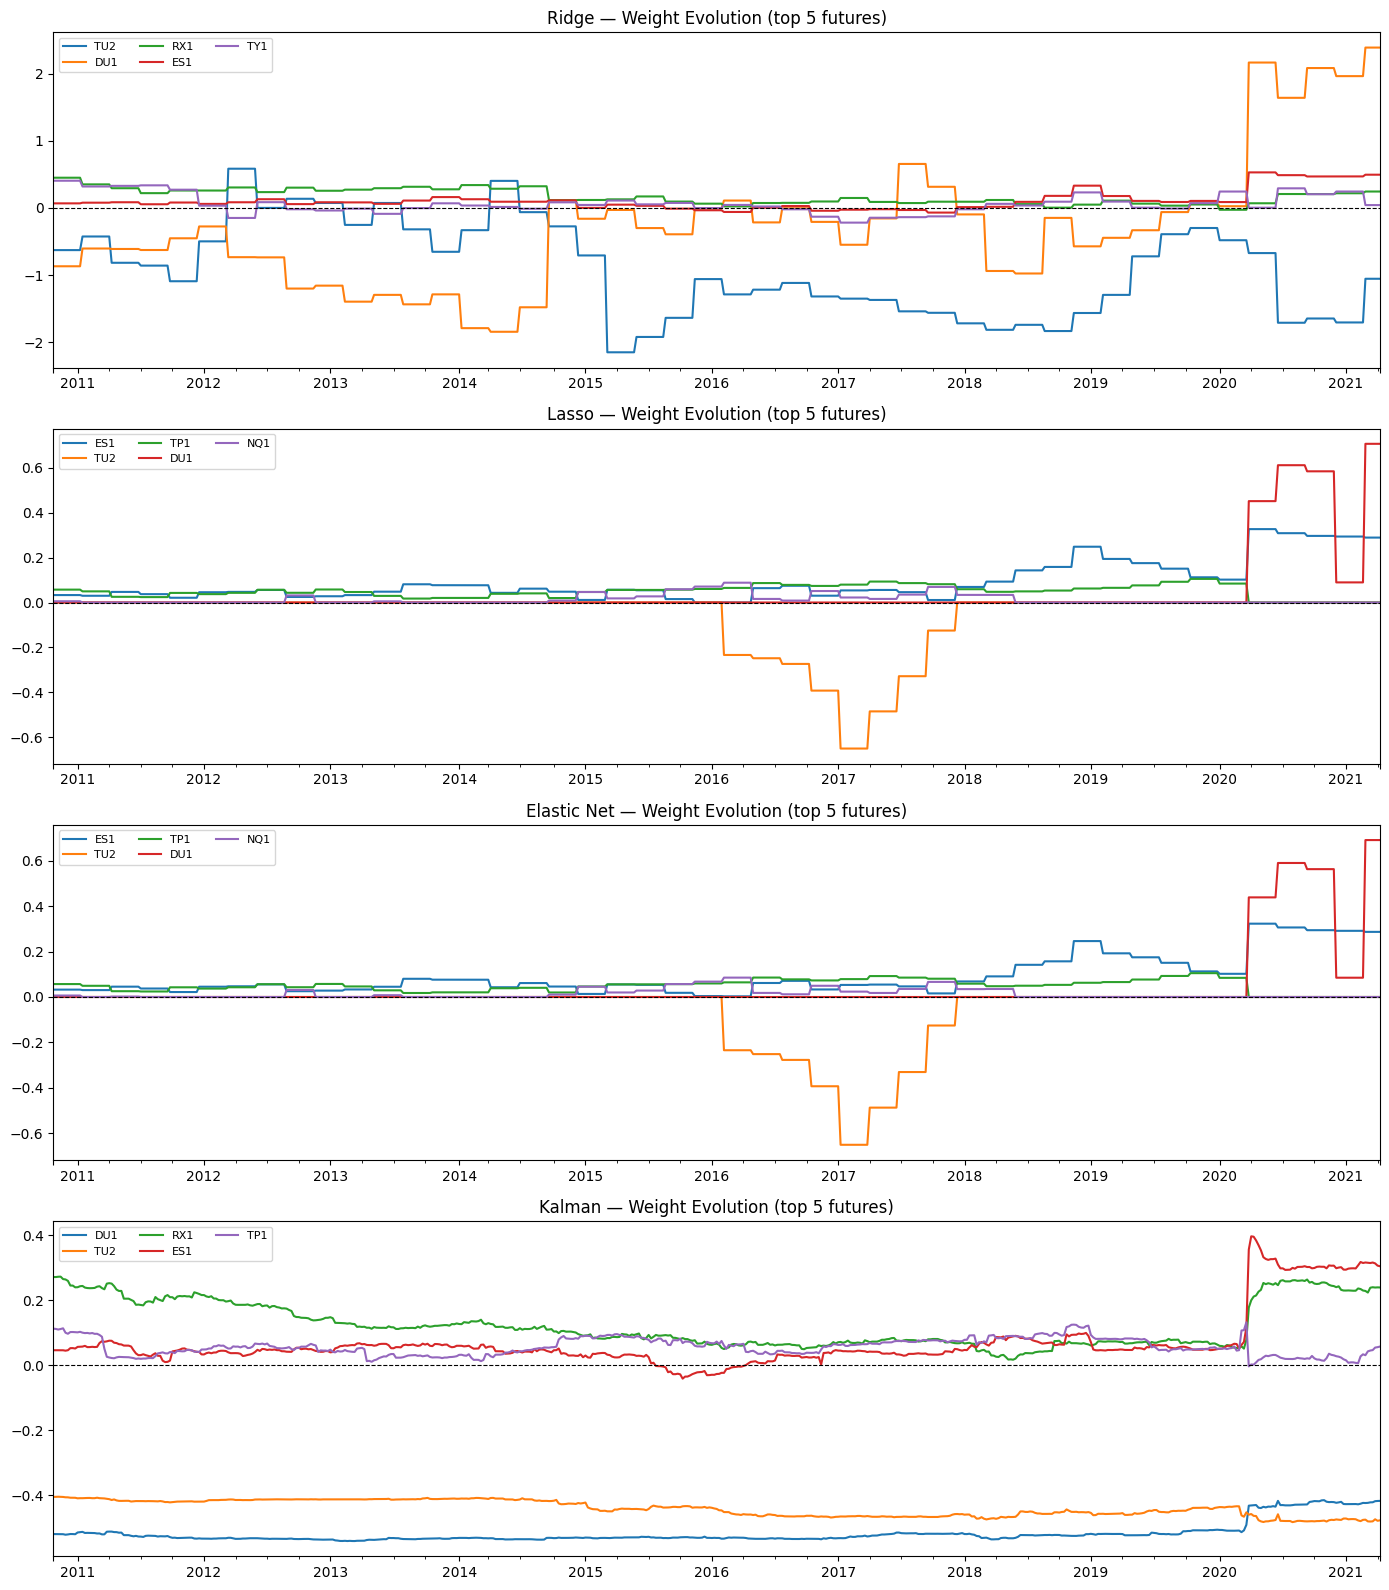

In [6]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))

for ax, (name, res) in zip(axes, results.items()):
    w = res["weights"].loc[common_idx]
    # Show only the top-5 by mean absolute weight to keep plots readable
    top5 = w.abs().mean().nlargest(5).index
    w[top5].plot(ax=ax)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"{name} — Weight Evolution (top 5 futures)")
    ax.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

---
## 5. Rebalancing Frequency Analysis

More frequent rebalancing → better tracking but higher costs. We test the best Elastic Net across different rebalancing intervals.

In [7]:
best_model = ElasticNet(**best_params, fit_intercept=False, max_iter=5000)

rebal_table = runner.analyze_rebalancing(
    model=best_model,
    freqs=[1, 2, 4, 8, 13],   # weekly, bi-weekly, monthly, bi-monthly, quarterly
    rolling_window=156
)

styled_rebal_table = rebal_table.style.apply(highlight_best, axis=0).format(precision=3)

print("=== Net Performance vs Rebalancing Frequency ===")
print("(Rebalance every N weeks)")
display(styled_rebal_table)

# Add best result (less Tracking Error) to metrics.df and results
best_freq = rebal_table["Tracking Error (%)"].idxmin()
metrics_df.loc[f"Elastic Net (Freq={best_freq})"] = rebal_table.loc[best_freq]
bt_freq = RollingBacktester(
    rolling_window=bt.rolling_window,
    rebalance_every=best_freq,
    var_threshold=bt.var_threshold,
    var_confidence=bt.var_confidence,
    var_horizon=bt.var_horizon,
    transaction_cost_bps=bt.transaction_cost_bps,
    annual_factor=bt.annual_factor
)
runner_freq = ModelRunner(bt_freq, X, y)
results[f"Elastic Net (Freq={best_freq})"] = runner_freq.run_models({
    "EN": ElasticNet(**best_params, fit_intercept=False, max_iter=5000)
})["EN"]

=== Net Performance vs Rebalancing Frequency ===
(Rebalance every N weeks)


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
1,2.490,3.100,3.988,0.456,0.197,0.294
2,2.548,3.080,3.949,0.466,0.214,0.294
4,2.600,3.000,3.920,0.468,0.229,0.291
8,2.441,2.827,3.842,0.481,0.192,0.283
13,2.589,2.949,3.883,0.476,0.228,0.280


---
## 6. Kalman Filter — Process Noise Sensitivity

The Kalman Filter's key hyperparameter is `process_noise` — how fast it believes weights change. Low values → slow adaptation; high values → noisy, reactive weights.

In [ ]:
noise_grid = [1e-5, 1e-4, 1e-3, 1e-2]
kf_metrics = {}

for pn in noise_grid:
    res_kf = runner.run_models({
        "KF": KalmanFilterStrategy(init_window=104, process_noise=pn, transaction_cost_bps=5.0)
    })
    kf_metrics[pn] = res_kf["KF"]["metrics"]

kf_table = pd.DataFrame(kf_metrics).T.round(3)
kf_table.index.name = "Process Noise"

styled_kf_table = rebal_table.style.apply(highlight_best, axis=0).format(precision=3)

print("=== Net Performance vs Process Noise ===")
display(styled_kf_table)

# Find parameter with low tracking error
best_pn = kf_table["Tracking Error (%)"].idxmin()
metrics_df.loc[f"Kalman (Noise={best_pn:.0e})"] = kf_table.loc[best_pn]
results[f"Kalman (Noise={best_pn:.0e})"] = runner.run_models({
    "KF": KalmanFilterStrategy(init_window=104, process_noise=best_pn, transaction_cost_bps=5.0)
})["KF"]
print(f"\nBest process_noise: {best_pn:.0e}")

---
## 7. Model Comparison for index HFRXGL

FINAL MODEL COMPARISON — NET OF TRANSACTION COSTS


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,3.679,4.462,4.507,0.471,0.438,2.380
Lasso,2.670,3.079,3.924,0.474,0.246,0.285
Elastic Net,2.656,3.062,3.920,0.474,0.243,0.283
Kalman,1.987,2.944,4.031,0.421,0.013,1.407
Elastic Net (Freq=8),2.441,2.827,3.842,0.481,0.192,0.283
Kalman (Noise=1e-05),1.960,2.682,3.852,0.460,0.006,1.410



 Best by Tracking Error : Elastic Net (Freq=8)
 Best by Correlation    : Elastic Net (Freq=8)


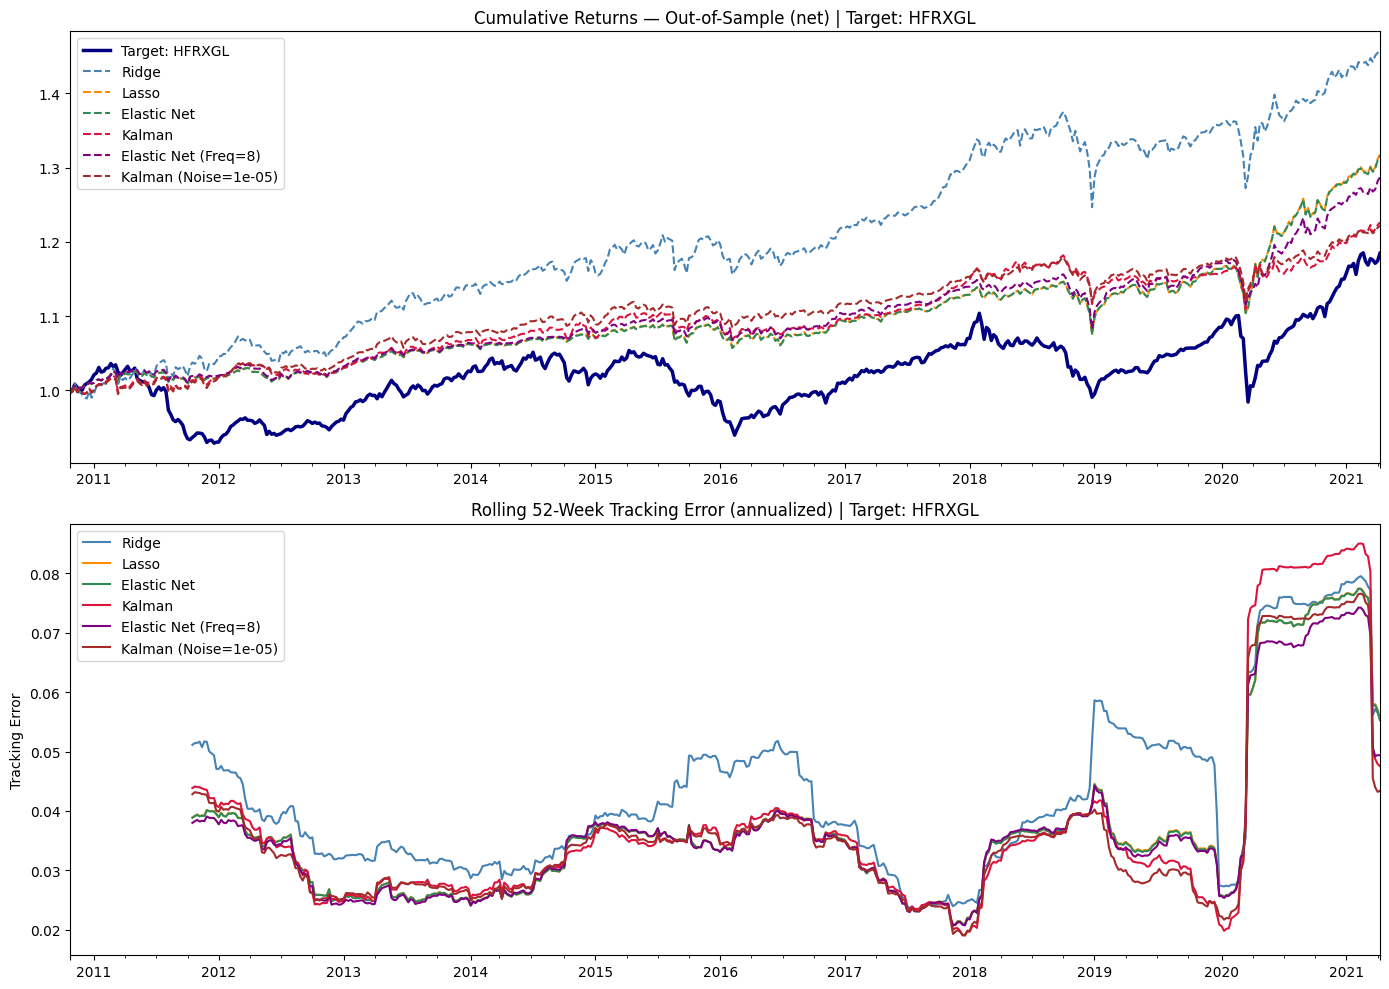

In [ ]:
print("=" * 60)
print("FINAL MODEL COMPARISON — NET OF TRANSACTION COSTS")
print("=" * 60)

styled_df = metrics_df[[
    "Ann. Return (%)", "Ann. Vol (%)",
    "Tracking Error (%)", "Correlation",
    "Info Ratio", "Avg Gross Exposure"
]].style.apply(highlight_best, axis=0).format(precision=3)
display(styled_df)

best_te_model   = metrics_df["Tracking Error (%)"].idxmin()
best_corr_model = metrics_df["Correlation"].idxmax()
print(f"\n Best by Tracking Error : {best_te_model}")
print(f" Best by Correlation    : {best_corr_model}")

fig, axes, common_idx, target_oos = plot_oos_comparison(results, y, annual_factor=52)

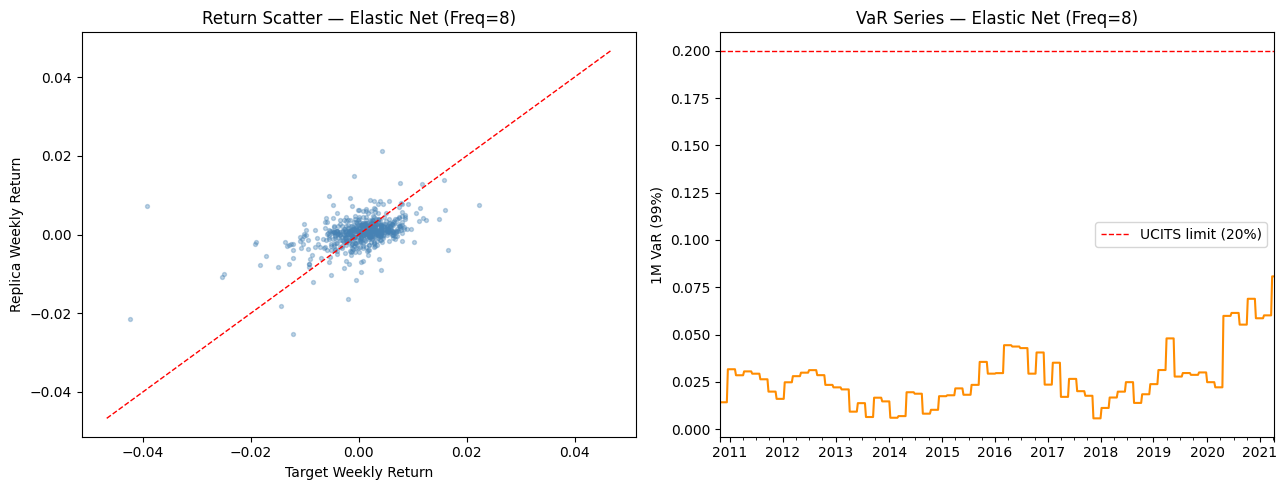

Average VaR (Elastic Net (Freq=8)): 2.69%
Maximum VaR (Elastic Net (Freq=8)): 8.07%
Threshold:   20.00%


In [ ]:
best_name = best_te_model
best_rep  = results[best_name]["replica_net"].loc[common_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Return scatter
axes[0].scatter(target_oos, best_rep, alpha=0.35, s=8, color="steelblue")
lim = max(abs(target_oos).max(), abs(best_rep).max()) * 1.1
axes[0].plot([-lim, lim], [-lim, lim], "r--", lw=1)
axes[0].set_xlabel("Target Weekly Return")
axes[0].set_ylabel("Replica Weekly Return")
axes[0].set_title(f"Return Scatter — {best_name}")

# VaR series
var_series = results[best_name]["var"].loc[common_idx].dropna()
var_series.plot(ax=axes[1], color="darkorange", lw=1.5)
axes[1].axhline(0.20, color="red", lw=1, linestyle="--", label="UCITS limit (20%)")
axes[1].set_title(f"VaR Series — {best_name}")
axes[1].set_ylabel("1M VaR (99%)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Let's look at the actual VaR values your model calculated
var = results[best_name]["var"].dropna()

print(f"Average VaR ({best_name}): {var.mean() * 100:.2f}%")
print(f"Maximum VaR ({best_name}): {var.max() * 100:.2f}%")
print(f"Threshold:   {bt.var_threshold * 100:.2f}%")

# Create vector of the final result for a final comparison between index
final_results = {}
best_metrics = metrics_df.loc[best_name].copy()
best_metrics["Best Model"] = best_name
best_metrics["Average VaR (%)"] = var.mean() * 100
best_metrics["Maximum VaR (%)"] = var.max() * 100
final_results["HFRXGL"] = best_metrics

---
## 8. MXWO


MXWO

=== OLS Baseline (In-Sample) ===
  R²               : 0.9627
  Tracking Error   : 3.38%
  Correlation      : 0.9812
  Gross Exposure   : 2.09x

           ES1     DU1    TU2     VG1     TP1     GC1     TY1     RX1    LLL1  \
Weight  0.6395 -0.4503  0.411  0.2078  0.1118  0.0763  0.0751 -0.0517  0.0473   

           CO1     NQ1  
Weight  0.0135 -0.0014  


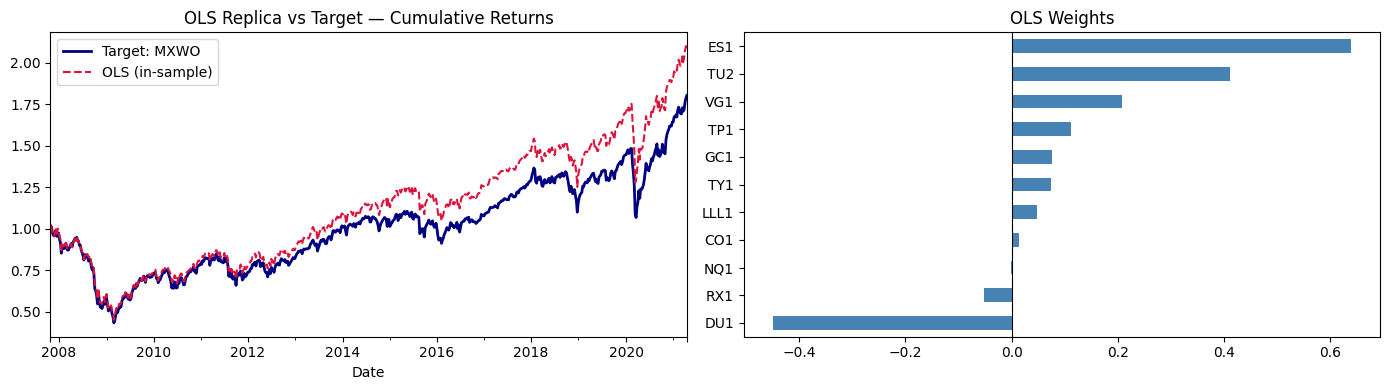


=== Elastic Net Best Params ===
Best params : {'alpha': 0.001, 'l1_ratio': 0.8}
Best TE     : 3.11%

=== Optimizing Rebalancing Frequency (Elastic Net) ===
  Freq=1 -> TE: 3.07%
  Freq=2 -> TE: 3.07%
  Freq=4 -> TE: 3.07%
  Freq=8 -> TE: 3.07%
  Freq=13 -> TE: 3.10%
Best Frequency: 2

=== Optimizing Process Noise (Kalman Filter) ===
  Noise=1e-05 -> TE: 3.11%
  Noise=1e-04 -> TE: 3.12%
  Noise=1e-03 -> TE: 3.27%
  Noise=1e-02 -> TE: 3.72%
Best Noise: 1e-05

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,10.949,14.771,3.236,0.976,0.447,2.734
Lasso,11.289,14.736,3.111,0.978,0.575,1.051
Elastic Net,11.307,14.753,3.110,0.978,0.580,1.112
Kalman,10.302,14.844,3.123,0.979,0.267,1.592
Elastic Net (Freq=2),11.208,14.729,3.066,0.979,0.557,1.110
Kalman (Noise=1e-05),10.514,14.766,3.111,0.979,0.336,1.519


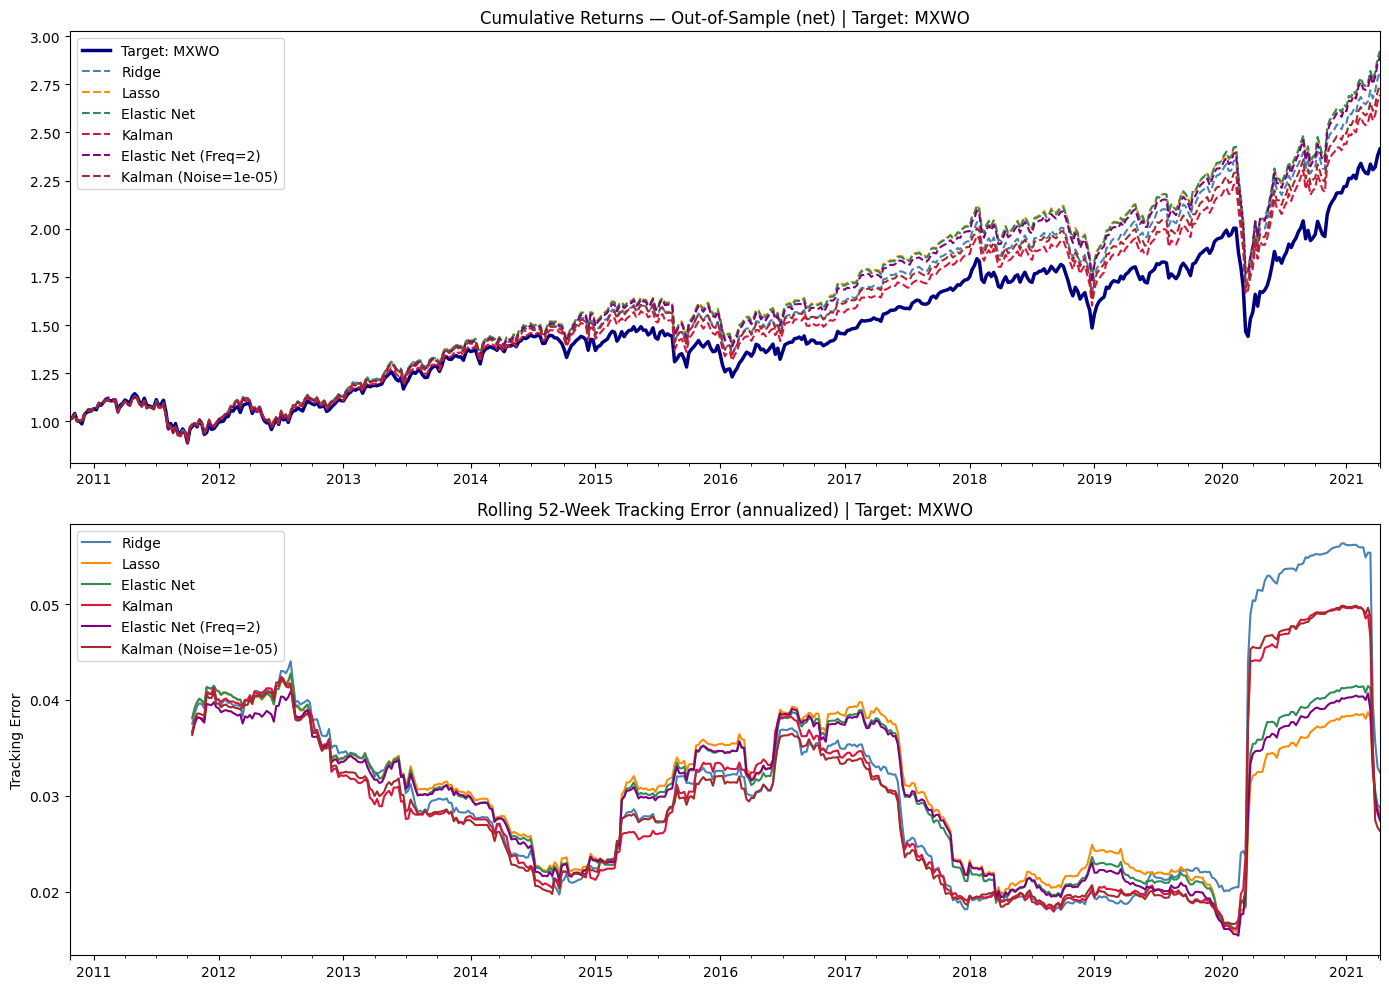

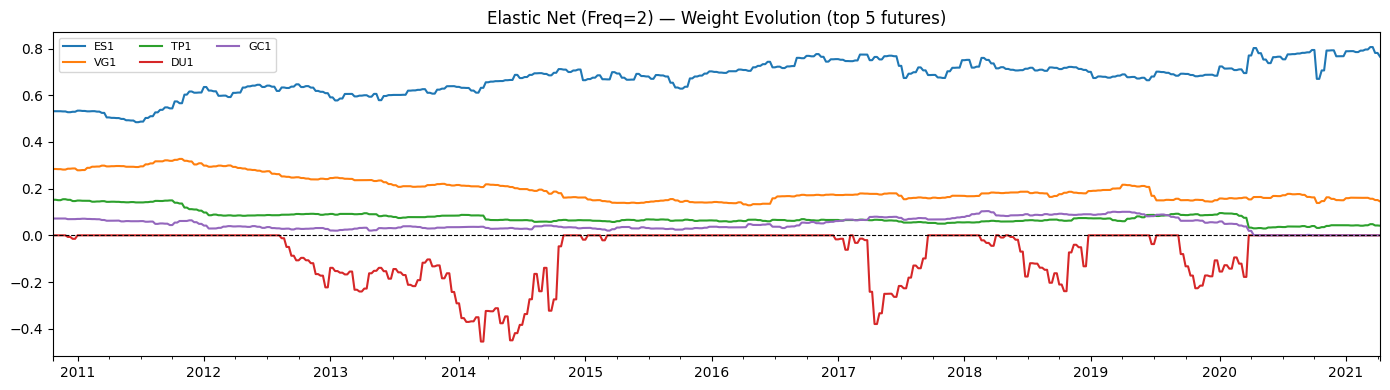

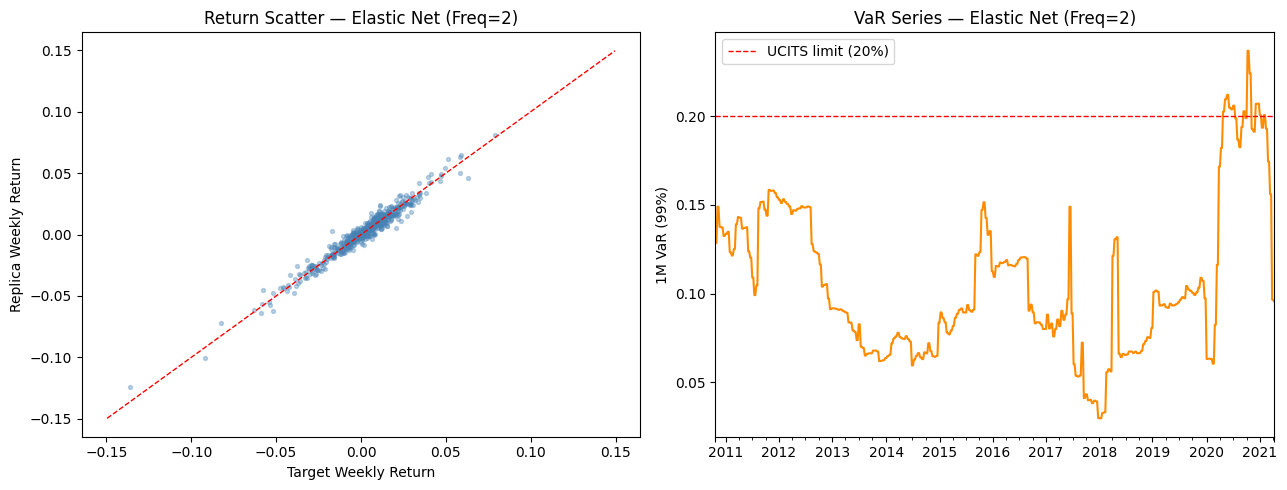

Average VaR (Elastic Net (Freq=2)): 10.57%
Maximum VaR (Elastic Net (Freq=2)): 23.68%
Threshold:   20.00%


In [ ]:
target = "MXWO"
final_results[target] = analizza_target(target, X, all_returns, bt, ANNUAL_FACTOR)

---
## 9. MXWD


MXWD

=== OLS Baseline (In-Sample) ===
  R²               : 0.9531
  Tracking Error   : 3.85%
  Correlation      : 0.9763
  Gross Exposure   : 2.09x

           ES1     DU1     TU2     VG1     TP1     GC1    LLL1     TY1  \
Weight  0.5779 -0.4456  0.4038  0.2193  0.1271  0.0877  0.0868  0.0808   

           RX1     CO1    NQ1  
Weight -0.0379  0.0166  0.011  


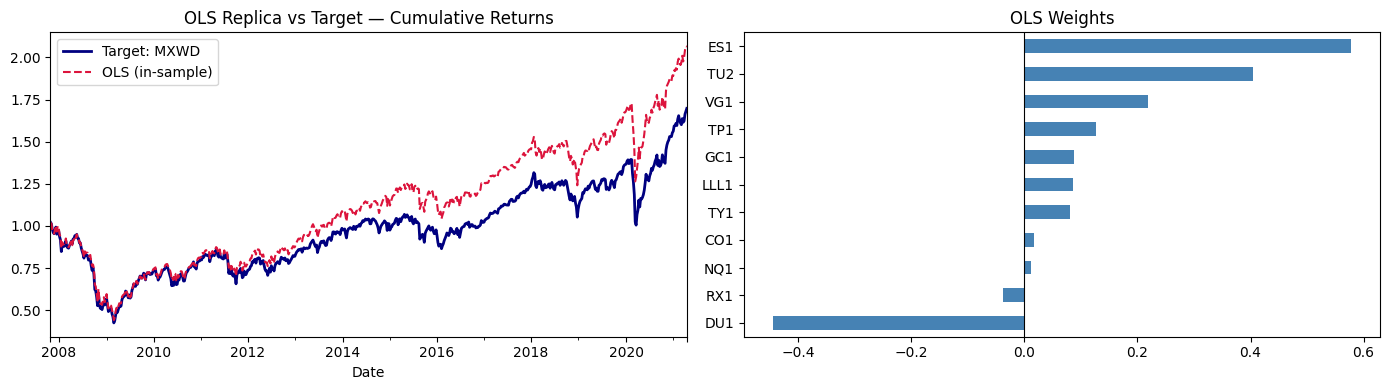


=== Elastic Net Best Params ===
Best params : {'alpha': 0.001, 'l1_ratio': 1.0}
Best TE     : 3.84%

=== Optimizing Rebalancing Frequency (Elastic Net) ===
  Freq=1 -> TE: 3.74%
  Freq=2 -> TE: 3.73%
  Freq=4 -> TE: 3.75%
  Freq=8 -> TE: 3.76%
  Freq=13 -> TE: 3.82%
Best Frequency: 2

=== Optimizing Process Noise (Kalman Filter) ===
  Noise=1e-05 -> TE: 3.69%
  Noise=1e-04 -> TE: 3.73%
  Noise=1e-03 -> TE: 3.91%
  Noise=1e-02 -> TE: 4.49%
Best Noise: 1e-05

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,10.967,14.756,4.038,0.963,0.553,2.887
Lasso,11.180,14.748,3.840,0.966,0.637,1.074
Elastic Net,11.180,14.748,3.840,0.966,0.637,1.074
Kalman,10.284,14.805,3.732,0.969,0.378,1.752
Elastic Net (Freq=2),11.094,14.717,3.734,0.968,0.633,1.073
Kalman (Noise=1e-05),10.440,14.673,3.693,0.970,0.424,1.644


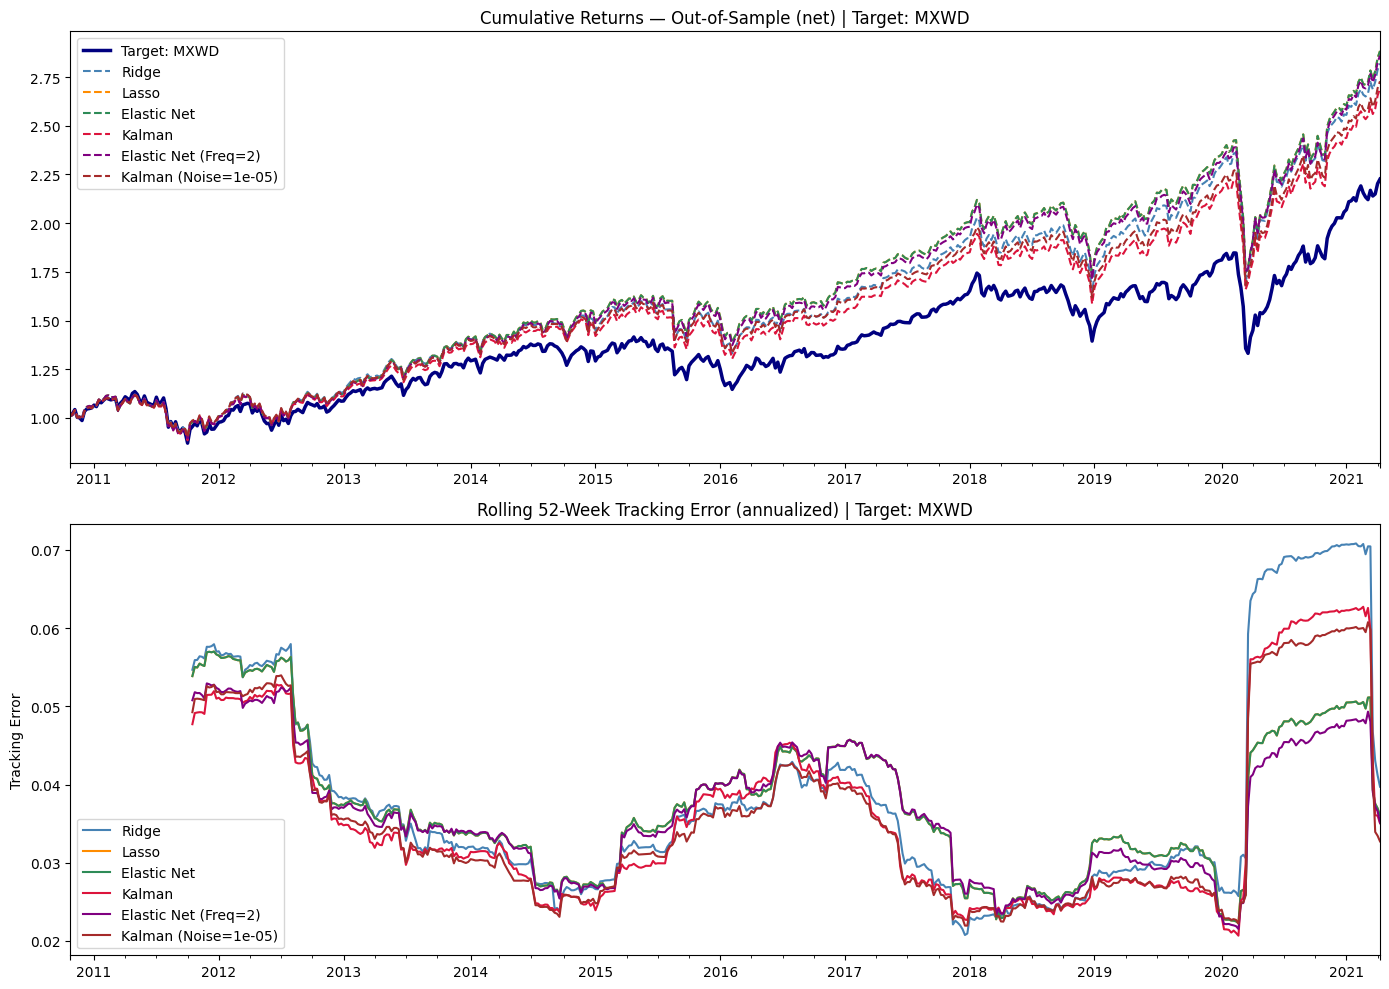

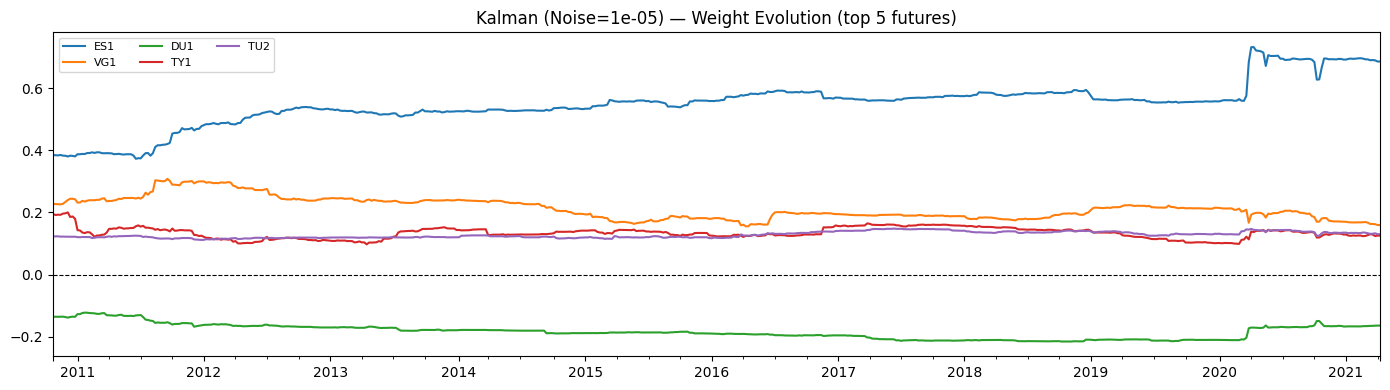

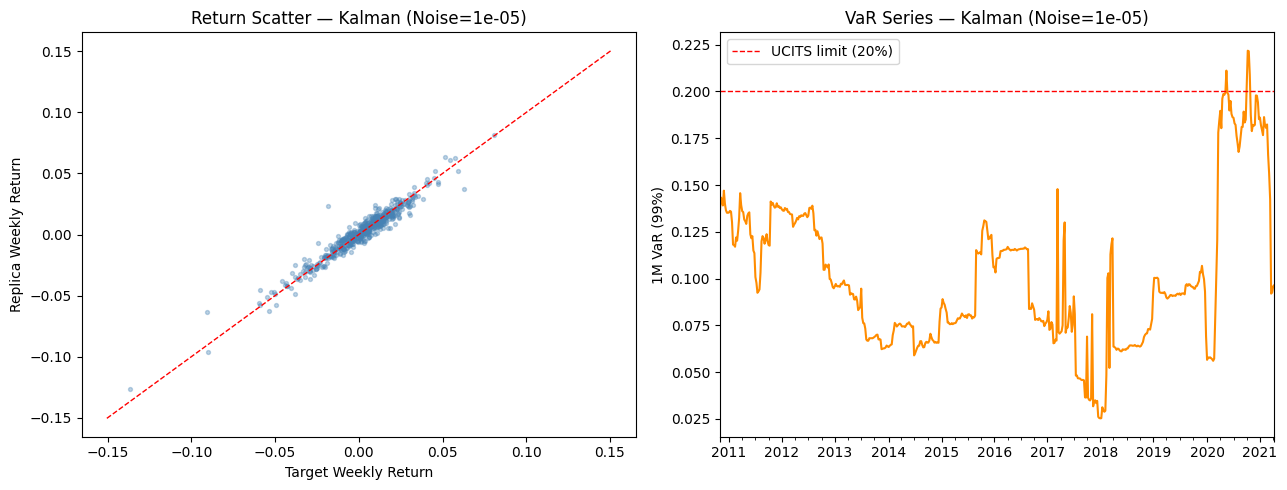

Average VaR (Kalman (Noise=1e-05)): 10.05%
Maximum VaR (Kalman (Noise=1e-05)): 22.18%
Threshold:   20.00%


In [ ]:
target = "MXWD"
final_results[target] = analizza_target(target, X, all_returns, bt, ANNUAL_FACTOR)

---
## 10. LEGATRUU


LEGATRUU

=== OLS Baseline (In-Sample) ===
  R²               : 0.5109
  Tracking Error   : 3.73%
  Correlation      : 0.7158
  Gross Exposure   : 2.02x

           TU2     DU1     TY1     RX1     GC1     ES1     NQ1     TP1  \
Weight  0.6684 -0.5831  0.3814  0.1099  0.0962  0.0818 -0.0275 -0.0272   

           VG1    LLL1     CO1  
Weight  0.0252  0.0146  0.0025  


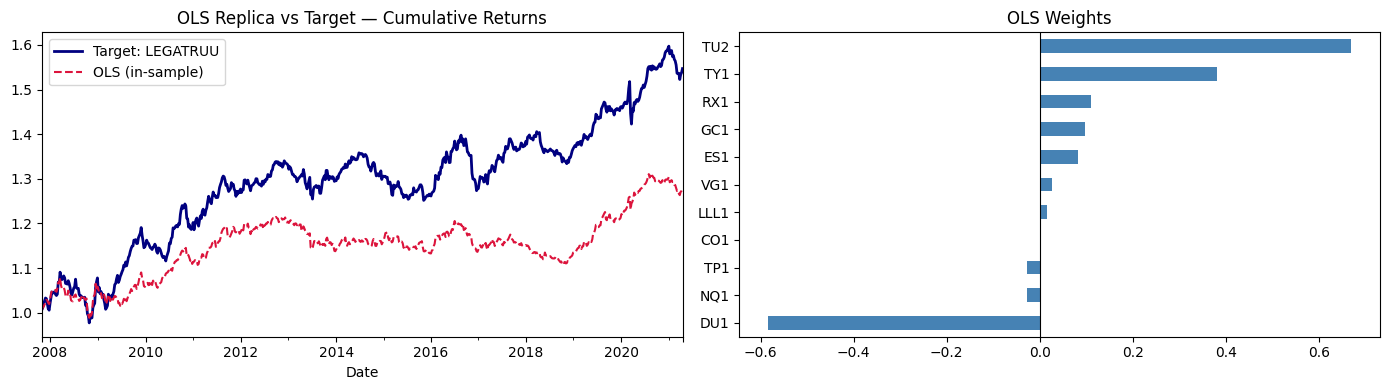


=== Elastic Net Best Params ===
Best params : {'alpha': 0.001, 'l1_ratio': 1.0}
Best TE     : 3.74%

=== Optimizing Rebalancing Frequency (Elastic Net) ===
  Freq=1 -> TE: 3.82%
  Freq=2 -> TE: 3.72%
  Freq=4 -> TE: 3.71%
  Freq=8 -> TE: 3.75%
  Freq=13 -> TE: 3.77%
Best Frequency: 4

=== Optimizing Process Noise (Kalman Filter) ===
  Noise=1e-05 -> TE: 3.62%
  Noise=1e-04 -> TE: 3.70%
  Noise=1e-03 -> TE: 3.92%
  Noise=1e-02 -> TE: 4.41%
Best Noise: 1e-05

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,1.419,4.825,3.840,0.686,-0.207,4.007
Lasso,1.464,4.371,3.745,0.676,-0.200,1.324
Elastic Net,1.464,4.371,3.745,0.676,-0.200,1.324
Kalman,1.618,3.713,3.705,0.662,-0.281,1.222
Elastic Net (Freq=4),1.296,4.370,3.714,0.682,-0.247,1.346
Kalman (Noise=1e-05),1.711,3.456,3.617,0.675,-0.262,1.094


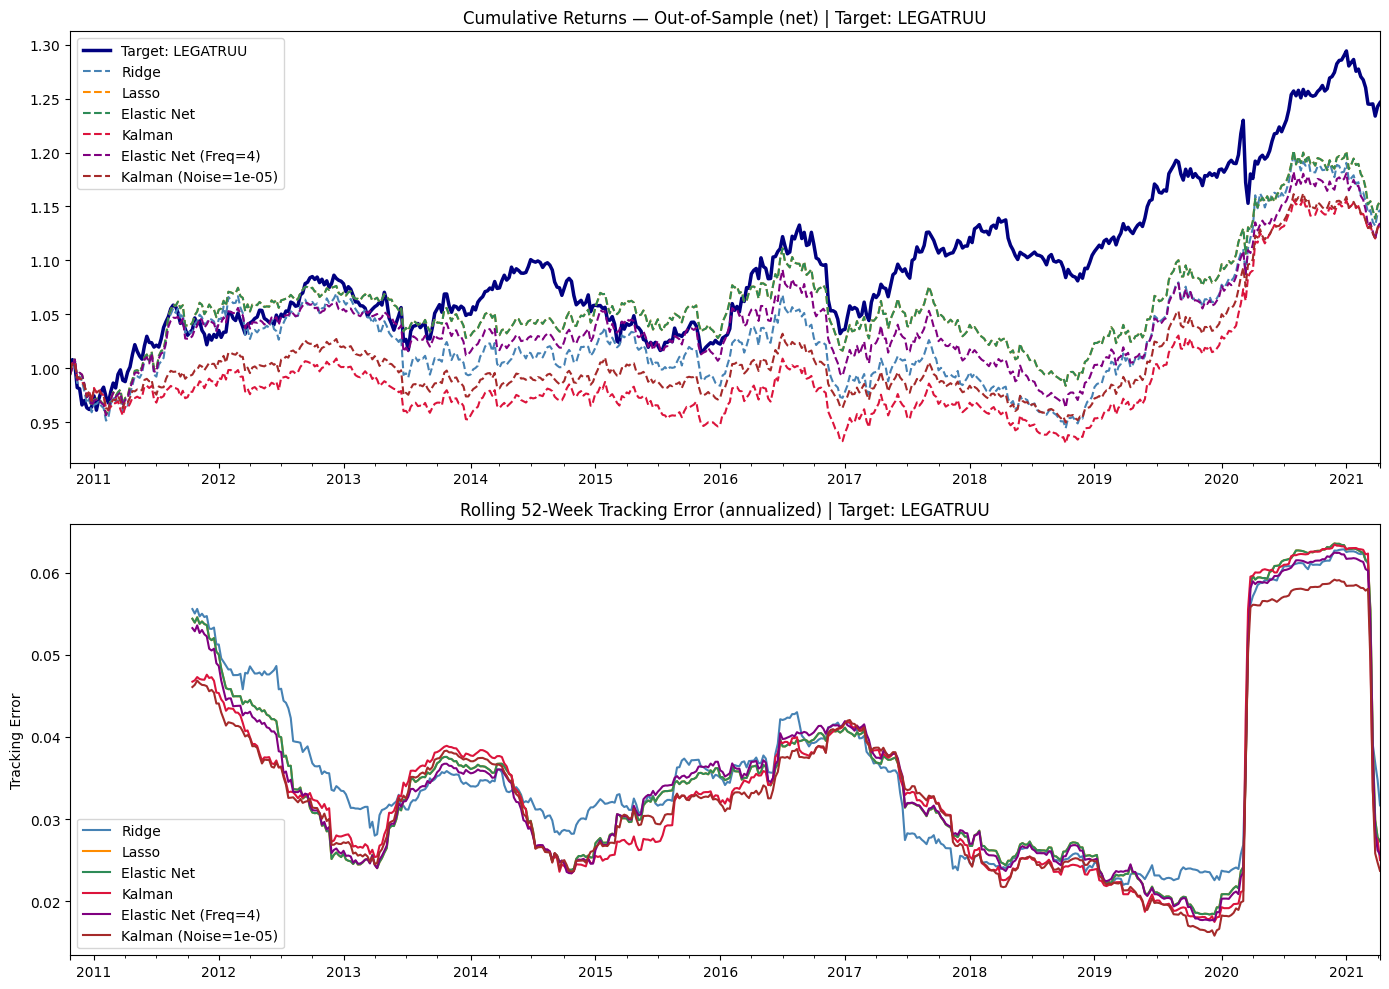

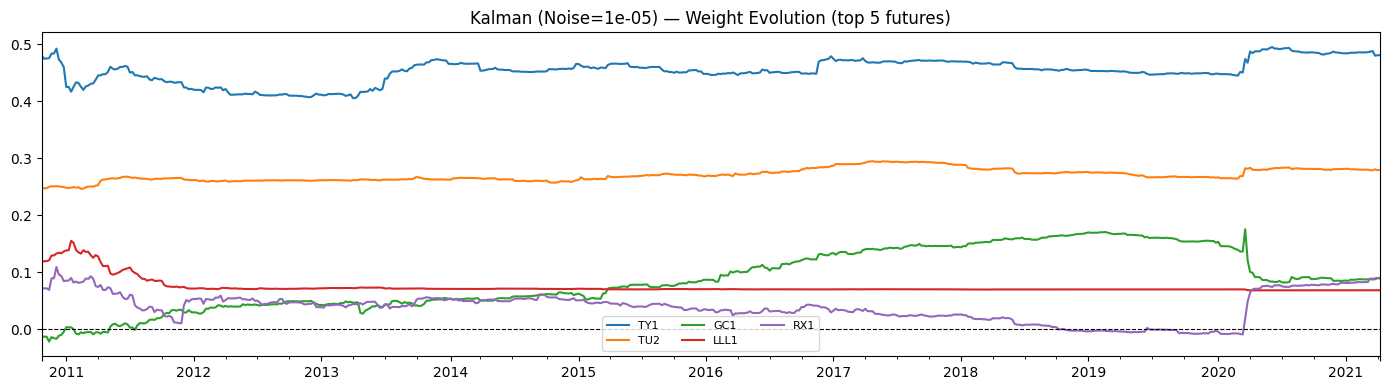

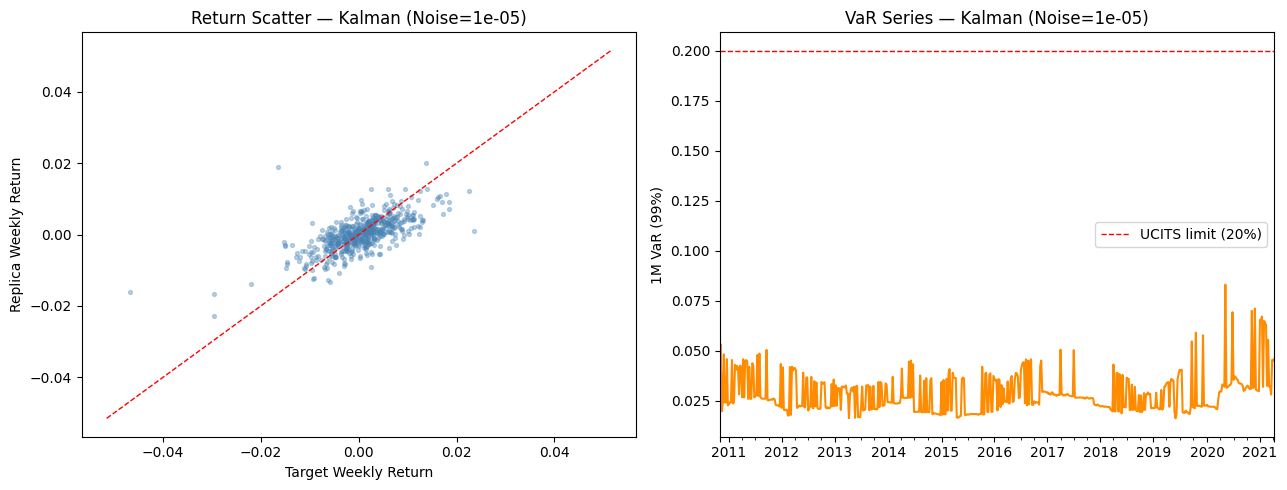

Average VaR (Kalman (Noise=1e-05)): 2.87%
Maximum VaR (Kalman (Noise=1e-05)): 8.31%
Threshold:   20.00%


In [ ]:
target = "LEGATRUU"
final_results[target] = analizza_target(target, X, all_returns, bt, ANNUAL_FACTOR)

---
## 11. Unconstrained Markowitz

| Base Index | Asset Class | Weight (Decimal) | Allocation (%) |
| :--- | :--- | :---: | :---: |
| **MXWO** | Developed Equities | `2.5915` | **+259.15%** |
| **MXWD** | Global Equities | `-2.4580` | **-245.80%** |
| **LEGATRUU** | Global Bonds | `0.9880` | **+98.80%** |
| **HFRXGL** | Hedge Funds | `-0.1215` | **-12.15%** |


MVO_Unconstrained_Index

=== OLS Baseline (In-Sample) ===
  R²               : 0.4813
  Tracking Error   : 4.52%
  Correlation      : 0.6954
  Gross Exposure   : 2.43x

          TU2     DU1    TY1     ES1     GC1    LLL1     TP1     RX1     NQ1  \
Weight  0.785 -0.6409  0.359  0.3009  0.0791 -0.0731 -0.0555  0.0553 -0.0548   

           VG1    CO1  
Weight  0.0254 -0.005  


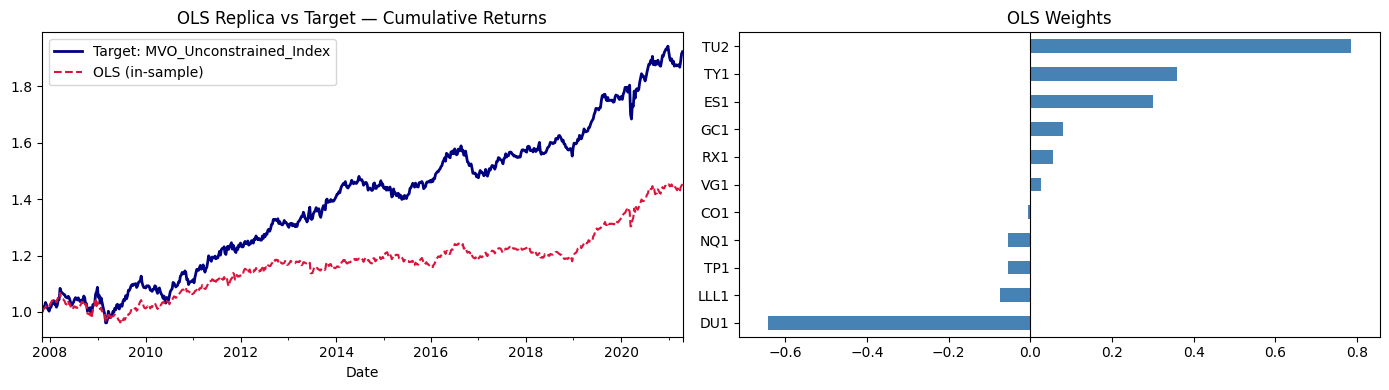


=== Elastic Net Best Params ===
Best params : {'alpha': 0.001, 'l1_ratio': 1.0}
Best TE     : 4.57%

=== Optimizing Rebalancing Frequency (Elastic Net) ===
  Freq=1 -> TE: 4.59%
  Freq=2 -> TE: 4.59%
  Freq=4 -> TE: 4.57%
  Freq=8 -> TE: 4.62%
  Freq=13 -> TE: 4.67%
Best Frequency: 4

=== Optimizing Process Noise (Kalman Filter) ===
  Noise=1e-05 -> TE: 4.41%
  Noise=1e-04 -> TE: 4.45%
  Noise=1e-03 -> TE: 4.66%
  Noise=1e-02 -> TE: 5.21%
Best Noise: 1e-05

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,3.485,5.926,4.853,0.648,-0.341,4.714
Lasso,4.032,4.691,4.581,0.619,-0.242,1.754
Elastic Net,4.032,4.691,4.581,0.619,-0.242,1.754
Kalman,2.919,4.067,4.450,0.633,-0.494,1.494
Elastic Net (Freq=4),3.976,4.733,4.571,0.623,-0.254,1.774
Kalman (Noise=1e-05),3.115,3.865,4.409,0.638,-0.454,1.480


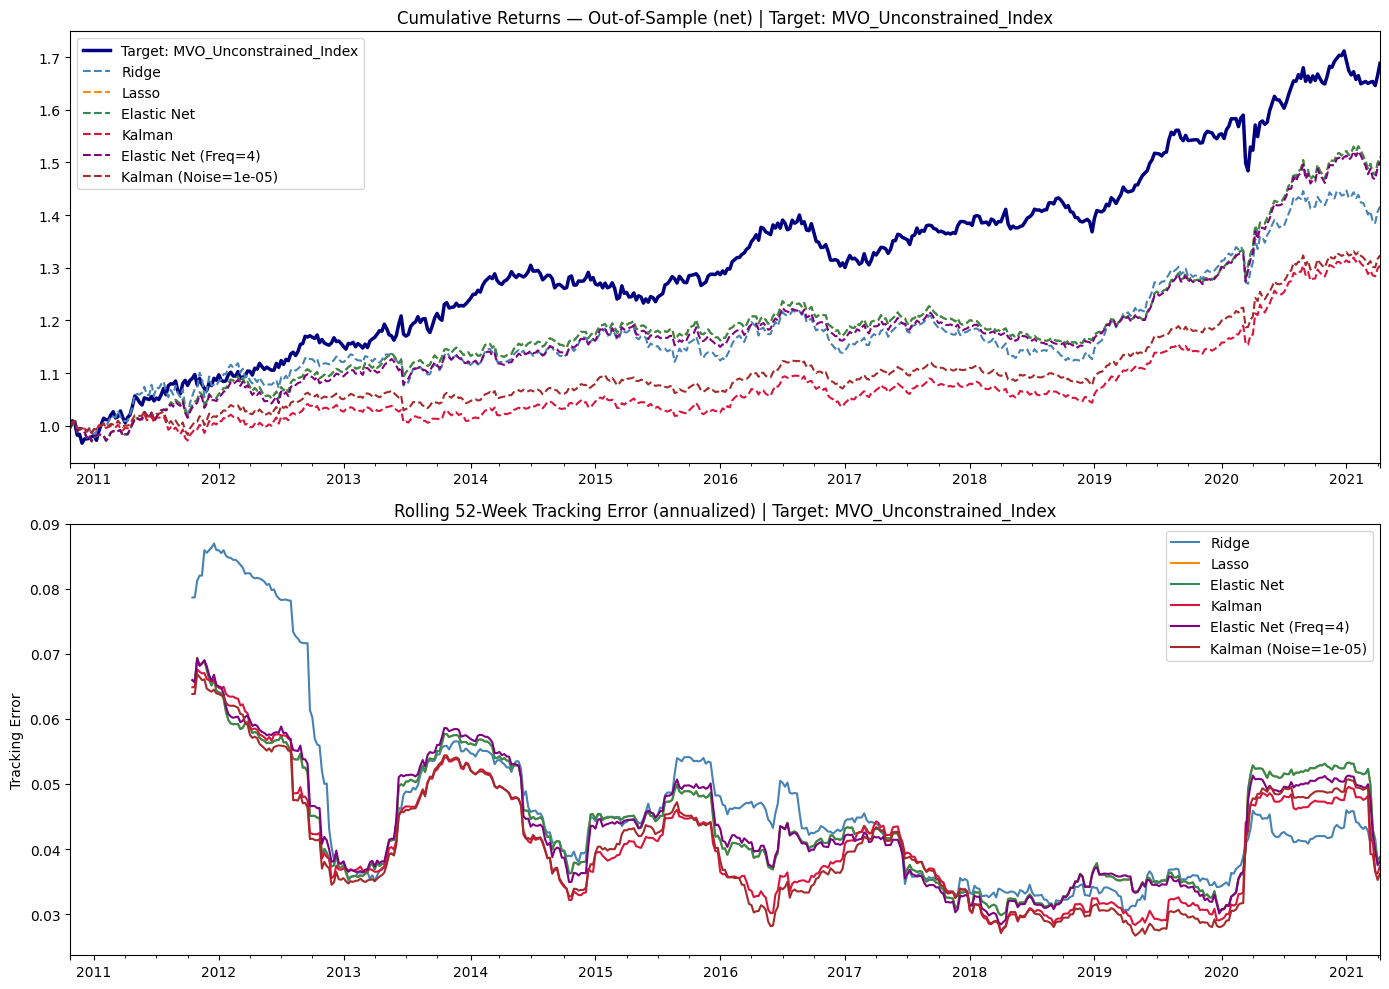

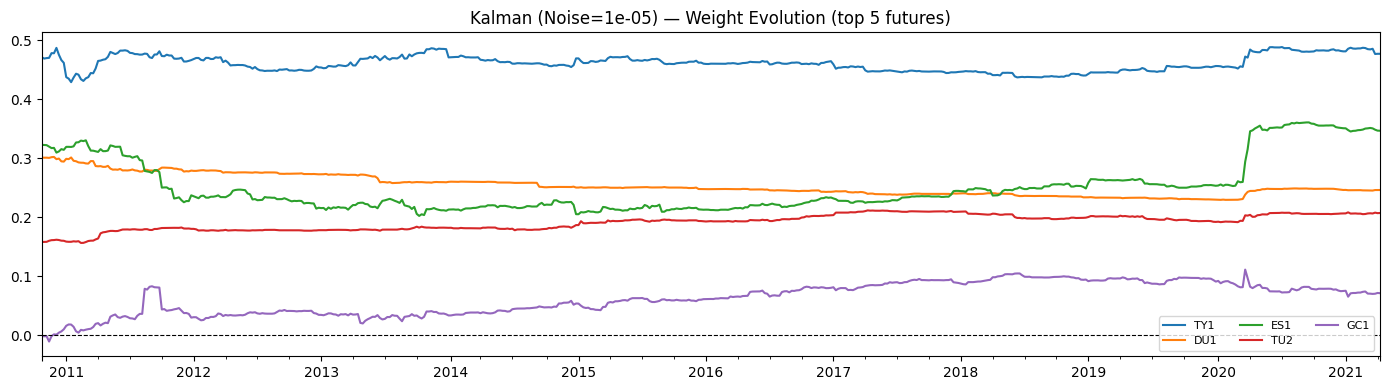

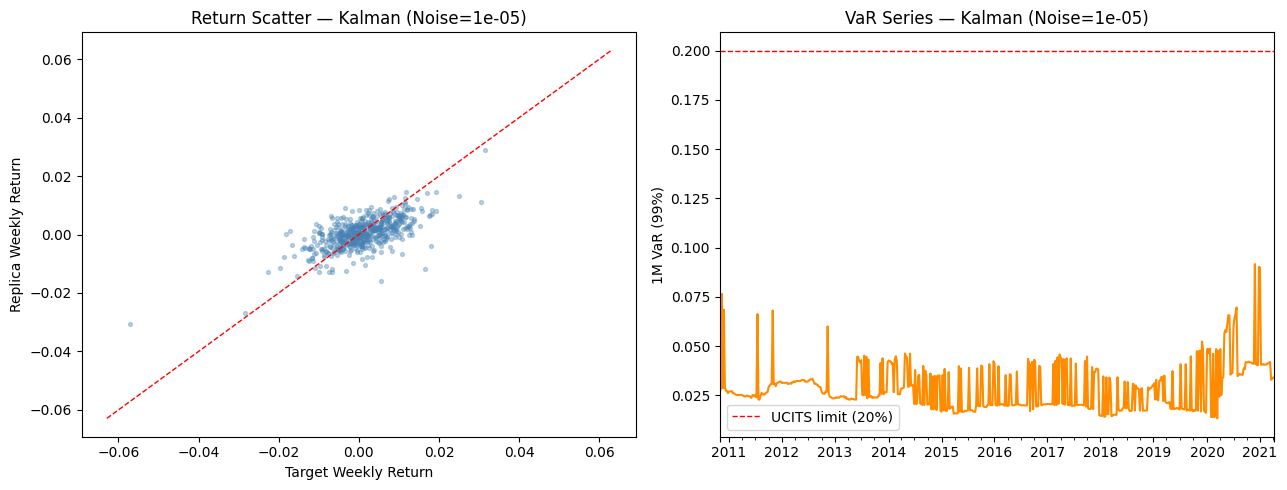

Average VaR (Kalman (Noise=1e-05)): 2.89%
Maximum VaR (Kalman (Noise=1e-05)): 9.17%
Threshold:   20.00%


In [ ]:
target = "MVO_Unconstrained_Index"
final_results[target] = analizza_target(target, X, all_returns, bt, ANNUAL_FACTOR)

---
## 12. Constrained Markowitz

| Base Index | Asset Class | Weight (Decimal) | Allocation (%) |
| :--- | :--- | :---: | :---: |
| **MXWO** | Developed Equities | `0.1009` | **10.09%** |
| **MXWD** | Global Equities | `0.0001` | **0.01%** |
| **LEGATRUU** | Global Bonds | `0.8989` | **89.89%** |
| **HFRXGL** | Hedge Funds | `0.0001` | **0.01%** |


MVO_Constrained_Index

=== OLS Baseline (In-Sample) ===
  R²               : 0.5572
  Tracking Error   : 3.62%
  Correlation      : 0.7471
  Gross Exposure   : 1.99x

           TU2     DU1     TY1     ES1     GC1     RX1     VG1     NQ1  \
Weight  0.6423 -0.5696  0.3504  0.1381  0.0942  0.0935  0.0436 -0.0249   

          LLL1     TP1     CO1  
Weight  0.0179 -0.0132  0.0037  


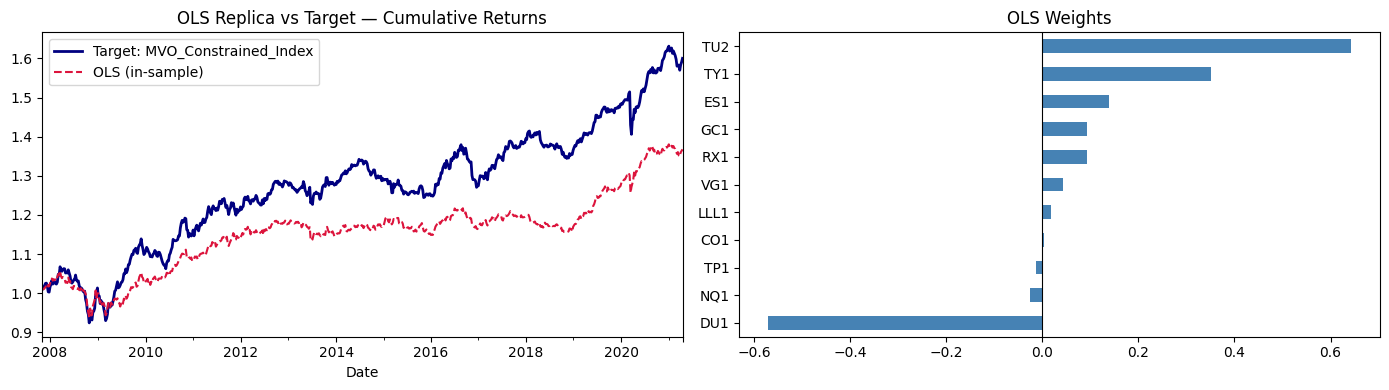


=== Elastic Net Best Params ===
Best params : {'alpha': 0.001, 'l1_ratio': 0.2}
Best TE     : 3.61%

=== Optimizing Rebalancing Frequency (Elastic Net) ===
  Freq=1 -> TE: 3.65%
  Freq=2 -> TE: 3.62%
  Freq=4 -> TE: 3.61%
  Freq=8 -> TE: 3.63%
  Freq=13 -> TE: 3.69%
Best Frequency: 4

=== Optimizing Process Noise (Kalman Filter) ===
  Noise=1e-05 -> TE: 3.51%
  Noise=1e-04 -> TE: 3.59%
  Noise=1e-03 -> TE: 3.79%
  Noise=1e-02 -> TE: 4.27%
Best Noise: 1e-05

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,2.669,4.782,3.660,0.713,-0.076,3.813
Lasso,3.097,4.369,3.751,0.676,0.040,1.164
Elastic Net,2.916,4.739,3.620,0.717,-0.009,2.757
Kalman,2.484,3.796,3.588,0.690,-0.240,1.215
Elastic Net (Freq=4),2.644,4.738,3.614,0.718,-0.084,2.780
Kalman (Noise=1e-05),2.606,3.553,3.507,0.703,-0.211,1.081


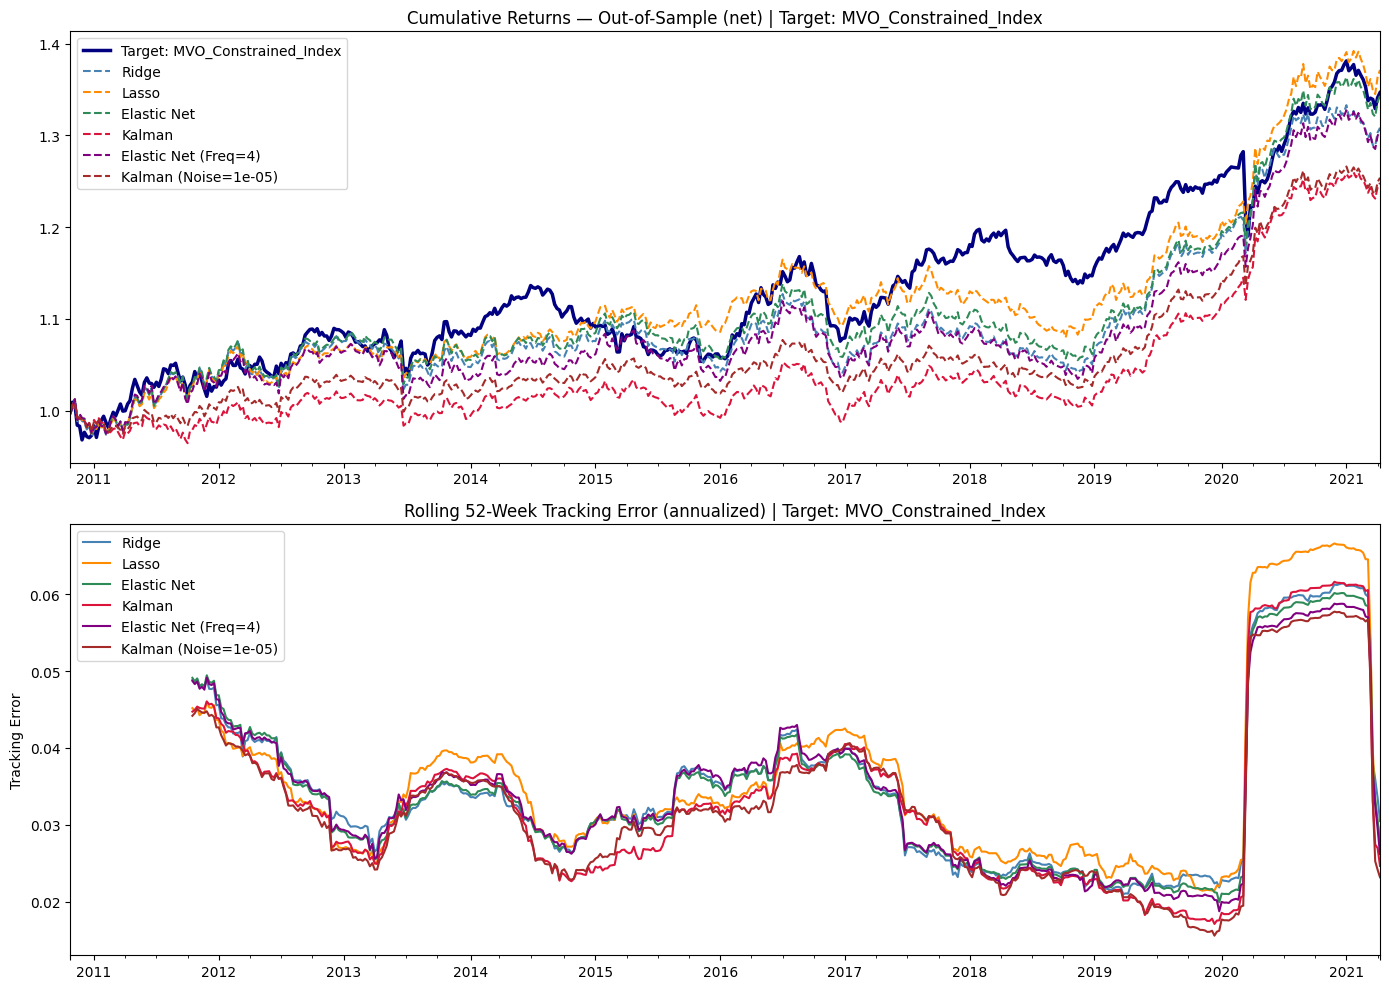

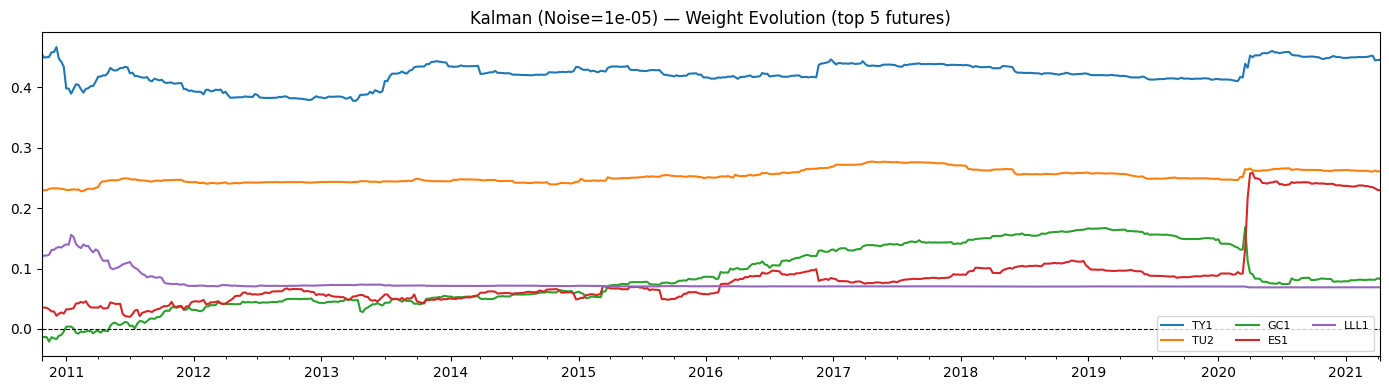

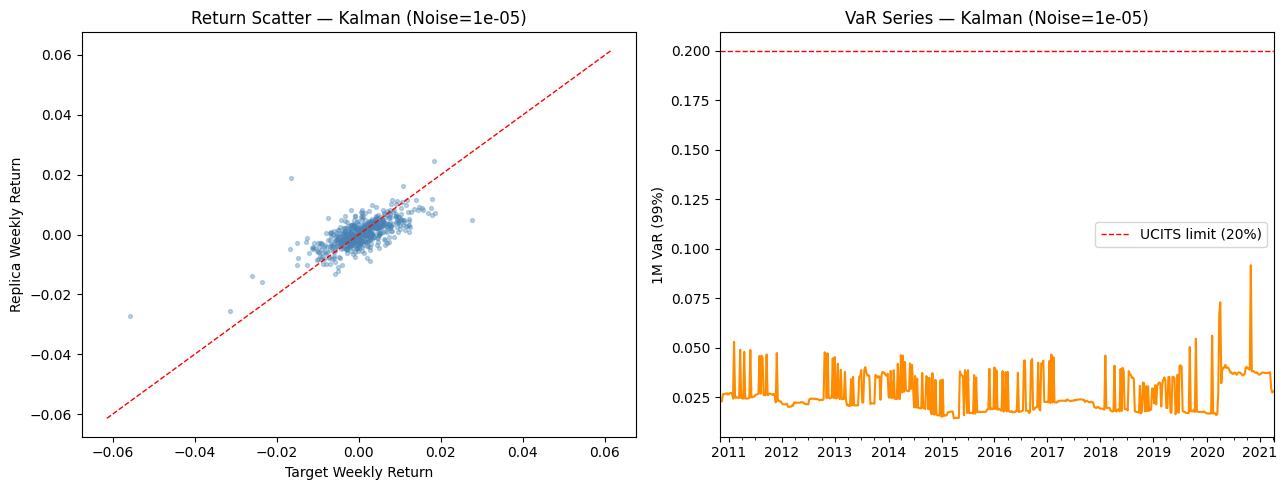

Average VaR (Kalman (Noise=1e-05)): 2.69%
Maximum VaR (Kalman (Noise=1e-05)): 9.17%
Threshold:   20.00%


In [ ]:
target = "MVO_Constrained_Index"
final_results[target] = analizza_target(target, X, all_returns, bt, ANNUAL_FACTOR)

---
## 13. Final Comparison
For best model we consider the model with the highest correlation

In [ ]:
final_df = pd.DataFrame(final_results).T

print("FINAL COMPARISON: BEST MODELS FOR EACH TARGET INDEX")
cols = ["Best Model", "Ann. Return (%)", "Ann. Vol (%)", "Sharpe", "Max DD (%)", 
        "Tracking Error (%)", "Correlation", "Info Ratio", "Avg Gross Exposure", 
        "Average VaR (%)", "Maximum VaR (%)"]
cols = [c for c in cols if c in final_df.columns] + [c for c in final_df.columns if c not in cols]
final_df = final_df[cols]

display(final_df)

FINAL COMPARISON: BEST MODELS FOR EACH TARGET INDEX


,Best Model,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure,Average VaR (%),Maximum VaR (%)
HFRXGL,Elastic Net (Freq=8),2.441,2.827,3.842,0.481,0.192,0.283,2.689945,8.073058
MXWO,Elastic Net (Freq=2),11.208,14.729,3.066,0.979,0.557,1.11,10.57408,23.683123
MXWD,Kalman (Noise=1e-05),10.44,14.673,3.693,0.97,0.424,1.644,10.048273,22.177716
LEGATRUU,Kalman (Noise=1e-05),1.711,3.456,3.617,0.675,-0.262,1.094,2.873757,8.30872
MVO_Unconstrained_Index,Kalman (Noise=1e-05),3.115,3.865,4.409,0.638,-0.454,1.48,2.89431,9.165556
MVO_Constrained_Index,Kalman (Noise=1e-05),2.606,3.553,3.507,0.703,-0.211,1.081,2.688351,9.168829
